# Multiple Linear Regression in Python with scikit-learn

### Predicting Quantity Sold from Advertising Cost and Item Price

👋 **Hello everyone!** Welcome to this short tutorial on **Multiple Linear Regression**.  

Today, we’ll be working with a **Sales dataset** to explore how different factors influence sales performance.  

In the next section, we’ll build a **predictive model** to forecast **Quantity Sold** based on **Advertising Cost** and **Item Price**.

🎯 This tutorial will cover:  

- Gaining an understanding of the dataset  
- Preparing and preprocessing the data  
- Implementing **multiple linear regression** using **scikit-learn**  
- Interpreting the regression results  
- Making predictions based on the linear model

### **Step 1: Import Libraries**

We’re using Pandas for data handling, NumPy for numerical operations, Matplotlib & Seaborn for visualisation, and Scikit-learn for regression modeling. Additionally, we’re suppressing all warning messages to keep the output clean and focused.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

# Suppress all warnings
import warnings
warnings.filterwarnings("ignore")

### **Step 2: Load the Dataset from CSV**  

Here’s our dataset, which contains 7 records, with each row representing a different scenario. Our goal is to find a relationship between Advertising Cost (£), Item Price (£), and Quantity Sold.  

In the context of linear regression, we refer to Advertising Cost (£) and Item Price (£) as independent variables, also known as input variables, predictors, or features. These are the factors we use to predict the Quantity Sold, which is our dependent variable, also called the output or target variable. Our regression model will help us understand how changes in advertising spend and item price affect sales.

In [2]:
# Load the CSV file
df = pd.read_csv("./data/sales_data.csv")

# Display the first few rows
df.head()

,Advertising Cost (£),Item Price (£),Quantity Sold
0,210,6,4750
1,1800,4,7300
2,2800,3,8500
3,500,3,7400
4,3300,6,6300


### **Step 3: Exploratory Data Analysis** 

Let's use the `info()` method from **pandas** to inspect the dataset structure, including column names, data types, and any missing values.

In [3]:
# Display dataset Overview
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7 entries, 0 to 6
Data columns (total 3 columns):
 #   Column                Non-Null Count  Dtype
---  ------                --------------  -----
 0   Advertising Cost (£)  7 non-null      int64
 1   Item Price (£)        7 non-null      int64
 2   Quantity Sold         7 non-null      int64
dtypes: int64(3)
memory usage: 300.0 bytes


Let's use the `describe()` method in pandas to generate summary statistics! This will provide insights into the mean, median, minimum, maximum, and standard deviation of our dataset.

In [4]:
# Display basic statistics
df.describe()

,Advertising Cost (£),Item Price (£),Quantity Sold
count,7.000000,7.000000,7.000000
mean,1415.714286,4.428571,6521.428571
std,1238.572527,1.272418,1281.228949
min,210.000000,3.000000,4750.000000
25%,450.000000,3.500000,5700.000000
50%,900.000000,4.000000,6300.000000
75%,2300.000000,5.500000,7350.000000
max,3300.000000,6.000000,8500.000000


Next, let's expore Which features are strongly related? Let’s examine the correlation between Advertising Cost, Item Price, and Quantity Sold to identify key relationships.  

Before building a regression model, it’s crucial to assess correlations between variables. This helps us determine how strongly the input features relate to the target variable and identify potential multicollinearity, where independent variables are highly correlated, which can impact model performance.

Correlation values range from -1 to 1. A value close to 1 indicates a strong positive correlation, meaning that as one variable increases, the other also increases. A value close to -1 suggests a strong negative correlation, where an increase in one variable results in a decrease in another. If the correlation is close to 0, it means there's no significant linear relationship between the variables.

#### **🔹 Interpreting Correlation**
- The correlation values range from **-1 to 1**:
  - **Close to 1:** Strong **positive correlation** (e.g., as Advertising increases, Sales increase).
  - **Close to -1:** Strong **negative correlation** (e.g., as Price increases, Sales decrease).
  - **Close to 0:** **No correlation** (no linear relationship).

Let's talk about **multicollinearity**. This occurs when two independent variables are highly correlated, typically above 0.8 or below -0.8. When this happens, it becomes difficult to determine the individual impact of each variable on the target, making the model less reliable. To fix this remove one of the highly correlated variables to reduce redundancy. there are other approaches as well.

📌 **What is Multicollinearity?**  
- When two **independent variables (inputs)** have a high correlation (e.g., above **0.8 or below -0.8**), it is known as **multicollinearity**.  

📌 **Why is it a Problem?**  
- It makes it difficult to determine the individual effect of each variable on the target, leading to unreliable model coefficients.  

📌 **How to Fix It?**  

1. **Remove One of the Highly Correlated Variables** – If two features are strongly correlated, consider dropping one to reduce redundancy.  
2. **Use Feature Engineering** – Transform variables (e.g., creating interaction terms) to better capture their impact.  
3. **Apply Principal Component Analysis (PCA)** – This reduces dimensionality while preserving important information.  
4. **Check Variance Inflation Factor (VIF)** – Identify and remove variables with high VIF scores to improve model stability.

Here’s our correlation matrix! It shows how strongly our features relate to each other. We can see that **Advertising Cost** has a moderate positive correlation with **Quantity Sold**, while **Item Price** has a strong negative correlation with **Quantity Sold**. This suggests that higher prices reduce sales, while more advertising boosts them.

In [5]:
# Calculate correlation matrix
correlation_matrix = df[['Advertising Cost (£)','Item Price (£)','Quantity Sold']].corr()
correlation_matrix

,Advertising Cost (£),Item Price (£),Quantity Sold
Advertising Cost (£),1.000000,0.039431,0.541954
Item Price (£),0.039431,1.000000,-0.793768
Quantity Sold,0.541954,-0.793768,1.000000


Now, let's visualise our correlation matrix with a heatmap. The colors indicate the strength and direction of relationships. Red means a strong positive correlation, while blue represents a strong negative correlation. From this, we can clearly see that item price and quantity sold have a strong negative correlation, while advertising cost has a positive impact on sales.

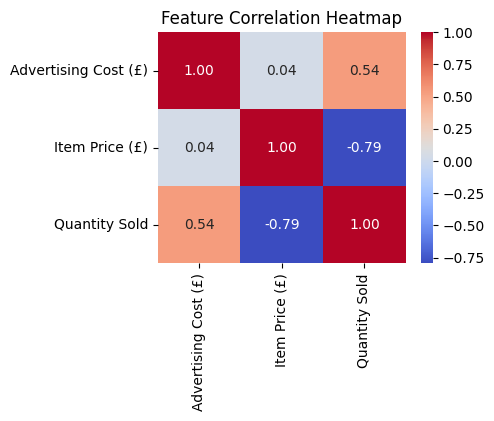

In [6]:
# Heatmap visualization of correlation
plt.figure(figsize=(4, 3))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f")
plt.title("Feature Correlation Heatmap")
plt.show()

Let's take a look at this pair plot. Each scatter plot shows the relationship between two features, helping us spot patterns or trends. On the diagonal, we have distribution plots that show how each variable is spread out. This is a great way to identify correlations and any potential outliers in our dataset.

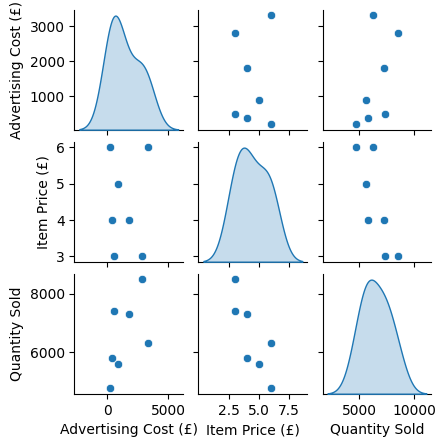

In [7]:
# Visualising relationships using pairplot
sns.pairplot(df, diag_kind='kde', height=1.5)
plt.show()

### **Step 4: Define Features and Target Variable** 

Now, let's define our features and target variable. The independent variables, also known as inputs, are **Advertising Cost** and **Item Price**, as these are the factors influencing sales. The dependent variable, also called the **output** or **target variable**, is **Quantity Sold**, which is what we are trying to predict based on the given inputs.

In [8]:
# Define variables
X = df[["Advertising Cost (£)", "Item Price (£)"]] # Independent, input or feature variables
y = df["Quantity Sold"] # Dependent, output or target variable

### **Step 5: Split Data into Training & Test Sets** 

In this step, we are splitting our dataset into training and testing sets. The training set will contain 80% of the data, while the testing set will contain the remaining 20%. This split is essential because it allows us to train our model on one portion of the data and then evaluate its performance on unseen data. By doing this, we ensure that our model generalises well to new inputs rather than simply memorising the training data. The training set will be used to fit the regression model, while the testing set will help us assess how well the model predicts the target variable based on new input values.

In [9]:
# Splitting data (80% training, 20% testing)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f"Training data points: {X_train.shape[0]}")
print(f"Testing data points: {X_test.shape[0]}")

Training data points: 5
Testing data points: 2


In [10]:
X_train

,Advertising Cost (£),Item Price (£)
5,900,5
2,2800,3
4,3300,6
3,500,3
6,400,4


### **Step 6: Train the Model**

Now, we move on to training our linear regression model. This is where the model learns the relationship between the independent variables and the target variable. 

We achieve this by fitting the model to the training data (80%), allowing it to determine the best coefficients that define this relationship. 

Once the model is trained, we extract key parameters: the intercept, which represents the predicted quantity sold when all input values are zero, and the coefficients, which indicate how much the target variable changes with a unit increase in each independent variable. 

These values provide insight into the influence of advertising cost and item price on sales performance.

In [11]:
# Train the model
model = LinearRegression()
model.fit(X_train, y_train)

LinearRegression()

In [12]:
# Print coefficients
print(f"Intercept: {model.intercept_}")
print(f"Coefficients: {model.coef_}")

Intercept: 9475.24932829364
Coefficients: [ 6.60367048e-01 -9.04435539e+02]


Here, we are writing out the equation for our linear regression model. The general equation includes the intercept and the coefficients for our two independent variables. Then, we substitute the actual values that our model has learned, showing exactly how advertising cost and item price affect quantity sold.

In [13]:
# Constructing the regression equation dynamically

from IPython.display import display, Math

# Extract model parameters
intercept = model.intercept_
beta_1, beta_2 = model.coef_  # Assuming two predictors

# Display the general regression equation
display(Math(r"\hat{Y} = \beta_0 + \beta_1 X_1 + \beta_2 X_2"))

# Construct and display the specific regression equation
equation = rf"\hat{{Y}} = {intercept:.2f} + ({beta_1:.2f} \times \text{{Advertising Cost (£)}}) + ({beta_2:.2f} \times \text{{Item Price (£)}})"
display(Math(equation))


<IPython.core.display.Math object>

<IPython.core.display.Math object>

### **Step 7: Make Predictions** 

Now it's time to put our model to the test! Using the `.predict` method, we generate predictions based on the test set (20%) and compare them with the actual values to see how well our model performs.

In [14]:
y_pred = model.predict(X_test)

# Display predicted vs actual values
df_results = pd.DataFrame({"Actual": y_test.values, "Predicted": y_pred})
print(df_results.head())

   Actual    Predicted
0    4750  4187.313175
1    7300  7046.167858


### **Step 8: Evaluate the Model** 

Time to evaluate our model's performance! A lower MSE means better accuracy, while RMSE provides an interpretable measure of error in the same units as the target variable. The R² score tells us how well the model explains the variation in sales data—closer to 1 means a better fit.  

For example, an R² score of **0.88** means that **88% of the variation in sales is explained by our model**, which indicates a good fit.  

Looking at RMSE, our model gives a value of **436.49**, meaning that, on average, our predictions deviate from actual sales by around **436 units**. This helps us understand the typical prediction error in real-world terms.  

For example, if our model predicts that a certain item will sell **7,000 units**, the actual sales could be **plus or minus 436 units**, meaning the expected range would be between **6,564 and 7,436 units**.

In [15]:
from sklearn.metrics import mean_squared_error, r2_score
import numpy as np

# Model evaluation metrics
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)  # Root Mean Squared Error
r2 = r2_score(y_test, y_pred)

# Print evaluation results
print(f"Mean Squared Error (MSE): {mse:.2f}")
print(f"Root Mean Squared Error (RMSE): {rmse:.2f}")
print(f"R-squared Score (R²): {r2:.4f}")


Mean Squared Error (MSE): 190523.61
Root Mean Squared Error (RMSE): 436.49
R-squared Score (R²): 0.8828


### **Step 9: Making Predictions Based on New Scenario**

Let’s put our model to the test with a new scenario!  

With £1500 spent on advertising for an item priced at £4, let’s predict how many units it could sell. This is where our model transforms data into valuable business insights!

In [16]:
new_data = np.array([[1500, 4]])  # Example: £1500 in ads, Item Price = £4
predicted_sales = model.predict(new_data)

print(f"Predicted Quantity Sold: {predicted_sales[0]:.0f}")

Predicted Quantity Sold: 6848


### 🎯 **Conclusion**  

We've successfully built a **Multiple Linear Regression model** to predict sales based on advertising spend and pricing!  

Here’s what we’ve discovered:  
- Increasing advertising spend generally leads to higher sales.  
- The impact of item price on sales isn’t always straightforward—it may not follow a simple pattern.  

This model provides valuable insights for making informed business decisions. 

Thank you for following along 🚀